In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from zmq import SCATTER

In [2]:
iris = datasets.load_iris() #sega e nummpy darray

X = iris.data
y = iris.target

target_names = iris.target_names
feature_names = iris.feature_names


number_of_classes = len(target_names)
number_of_features = len(feature_names)
number_of_instances = X.shape[0]

print("Број и имиња на класи:", number_of_classes, target_names)
print("Број и имиња на атрибути:", number_of_features, feature_names)
print("Број на податочни примероци:", number_of_instances)

Број и имиња на класи: 3 ['setosa' 'versicolor' 'virginica']
Број и имиња на атрибути: 4 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Број на податочни примероци: 150


In [6]:
df = datasets.load_iris(as_frame=True).frame #sega e data frame

In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df.describe() #statistika za sekoj atribut i targrtot

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [11]:
df.value_counts("target") #zanchi taman balansirano

target
0    50
1    50
2    50
Name: count, dtype: int64

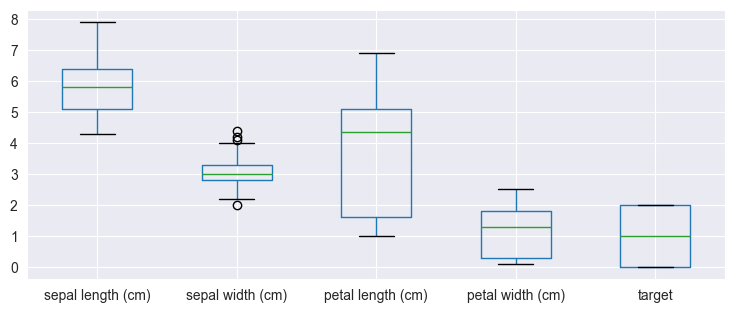

In [13]:
fig = plt.figure(figsize=(9, 3.5))
df.boxplot()
plt.show()


#Со box plot можеш веднаш да видиш распределба, средна вредност, варијанса и екстремни точки.

In [14]:
#varijansa e mala ako e mal kvadratot zanchi site se okolu srednata vr ako e golem zanchi se porazlichni i e pogolema varijansata

In [15]:
#sega kaj box plotojte za redojte sho se od konkretna klasa(za site klasi posebno istoto) pomala ke e varijansata

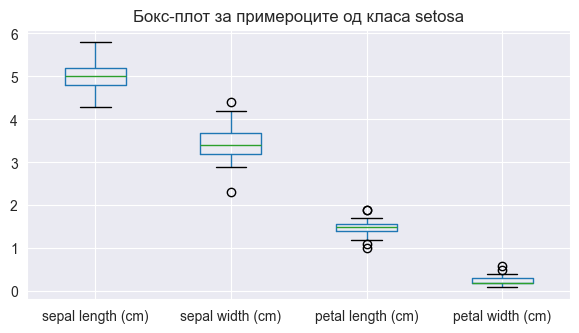

In [16]:
fig = plt.figure(figsize=(7, 3.5))
df[df.target==0].drop(['target'], axis=1).boxplot()
plt.title('Бокс-плот за примероците од класа setosa')
plt.show()

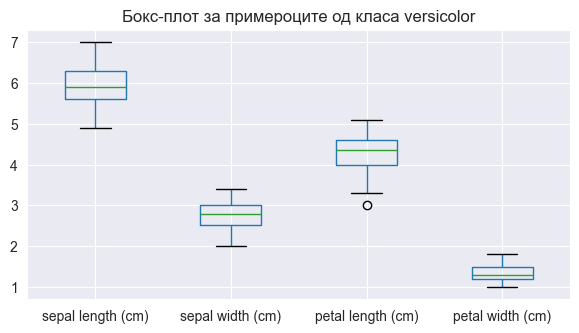

In [17]:
fig = plt.figure(figsize=(7, 3.5))
df[df.target==1].drop(['target'], axis=1).boxplot()
plt.title('Бокс-плот за примероците од класа versicolor')
plt.show()

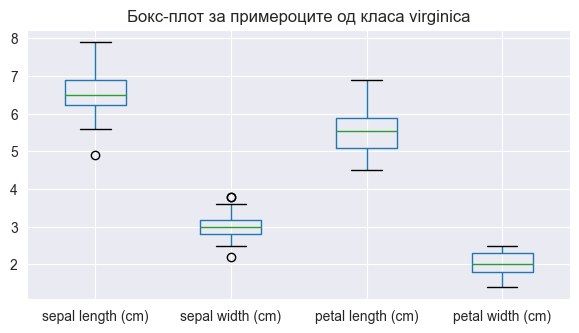

In [18]:
fig = plt.figure(figsize=(7, 3.5))
df[df.target==2].drop(['target'], axis=1).boxplot()
plt.title('Бокс-плот за примероците од класа virginica')
plt.show()

In [19]:
#kde dijagram





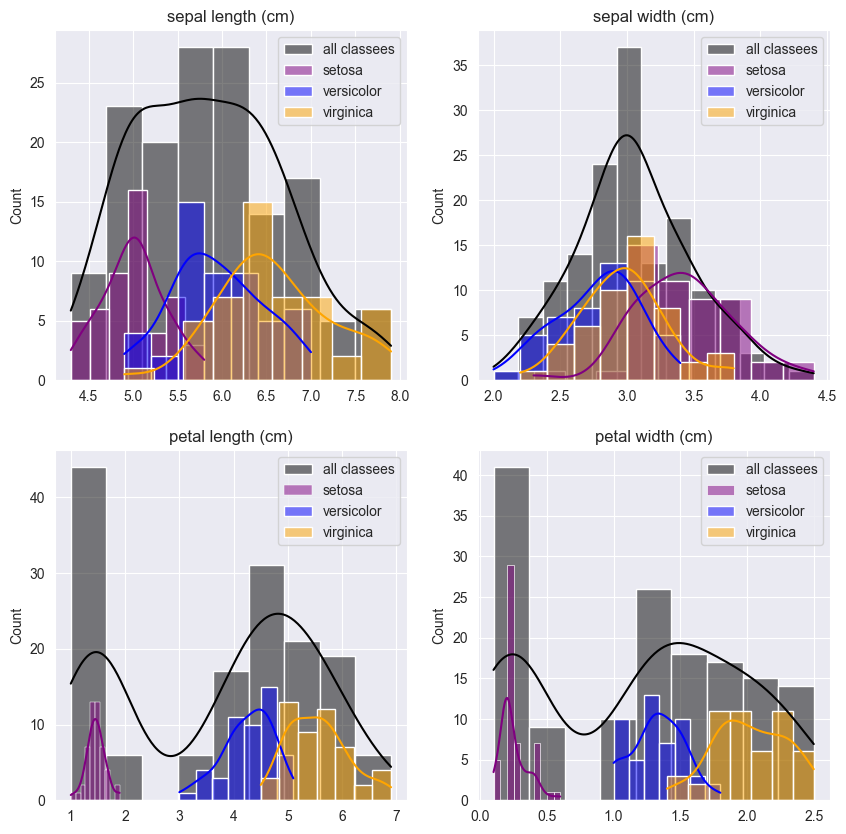

In [20]:
colors = ['purple','blue','orange']
fig = plt.figure(figsize=(10, 10))
fig.subplots(nrows=2, ncols=2)

for feature in range(number_of_features): # се прикажува посебен график за секој атрибут
    ax = plt.subplot(2,2, feature+1)
    plt.title(feature_names[feature])
    sns.histplot(X[:,feature],color='black',label='all classees',kde=True,stat="count") # се прикажува хистограм на вредностите на соодветниот атрибут без разлика во која класа припаѓаат
    for Class in range(number_of_classes): # се прикажува хистограм на вредностите на соодветниот атрибут за секоја класа посебно
        sns.histplot(X[y == Class,feature], color=colors[Class], label=target_names[Class],kde=True,stat="count") # Со X[y==c,i] се зема атрибутот i од примероците кои припаѓаат во класа c
    plt.legend()
plt.show()

In [21]:
#za da vidime koi atr ni se vazhni za klasifikacija
#petal length и petal width se vazhni za klasifikacija oti se razlichni za setosa zarazlichna od dr dve klasi


# ###
# Едномодална распределба
#
# Има еден врв на histogram-от или KDE кривата.
#
# Тоа значи дека податоците се концентрирани околу една вредност.
#
# Пример: ако сите petal length на Setosa се околу 1.5 cm, histogram-от ќе има еден врв таму.
#
# Двомодална распределба
#
# Има два врва на histogram-от.
#
# Тоа често се случува ако се спојуваат податоци од повеќе класи.
#
# Пример: ако ги земеш сите три класи за petal length, ќе добиеш еден врв за Setosa (~1.5) и втор врв за Versicolor/Virginica (~4–5.5).

###



# Зошто ова е важно за моделирање:
#
# Гаусов (Normal) модел претпоставува дека податоците се едномодални и „ѕвончиња“ форма (bell-shaped).
#
# Ако histogram-от е двомодален, тогаш една нормална дистрибуција не го опишува добро целиот сет на податоци.
#
# Во тој случај, треба да се користи генеративен модел кој може да работи со различни класи или комбинации, на пример Naive Bayes по класа или Mixture of Gaussians.

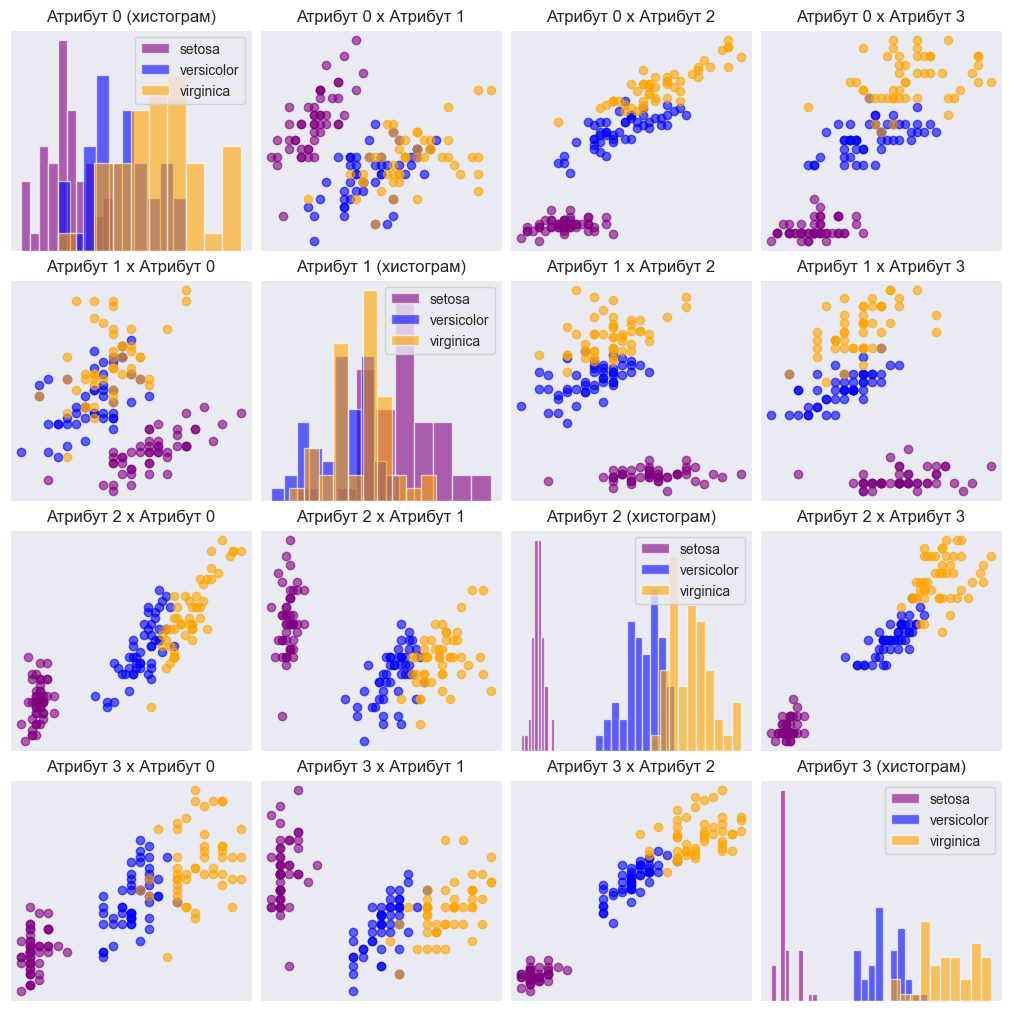

In [22]:
fig = plt.figure(figsize=(10, 10),layout='constrained')
fig.subplots(nrows=number_of_features, ncols=number_of_features)
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        ax = plt.subplot(number_of_features,number_of_features,number_of_features*feature_i + feature_j+1)
        if feature_i==feature_j:
            for color, i, target_name in zip(colors, [0, 1, 2], target_names):
                plt.hist(X[y == i, feature_i], alpha=.6, color=color, label=target_name)
            plt.title("Атрибут "+str(feature_i)+" (хистограм)")
            plt.legend()
        else:
            for color, i, target_name in zip(colors, [0, 1, 2], target_names):
                plt.scatter(X[y == i, feature_i], X[y == i, feature_j], alpha=.6, color=color, label=target_name)
            plt.title("Атрибут "+str(feature_i)+" x Атрибут "+str(feature_j))
        plt.xticks(())
        plt.yticks(())
plt.show()



In [23]:
# Histogramite
# Што гледаме тука:
#
# Каква е распределбата на атрибутот (едномодална или двомодална).
#
# Каде се центрирани вредностите за секоја класа.
#
# Дали постојат outliers (екстремни вредности).



#
# SCATTER
# Ако класите се јасно одделени во 2D простор, тоа значи дека овие два атрибути се добри за класификација.
#
# Ако точките формираат коса линија, атрибутите се позитивно или негативно корелирани.
#
# Ако точките на две класи се мешаат, границата на одлука ќе биде потешка.

In [24]:
#GUSTINA

In [29]:
g=sns.pairplot(df, hue="target",kind="kde",palette=colors)
sns.move_legend(g, "lower center",bbox_to_anchor=(.5, 1),ncol=3, title=None)
for t, l in zip(g._legend.texts, target_names):
    t.set_text(l)

In [27]:
#ISTI OVIE DVETE

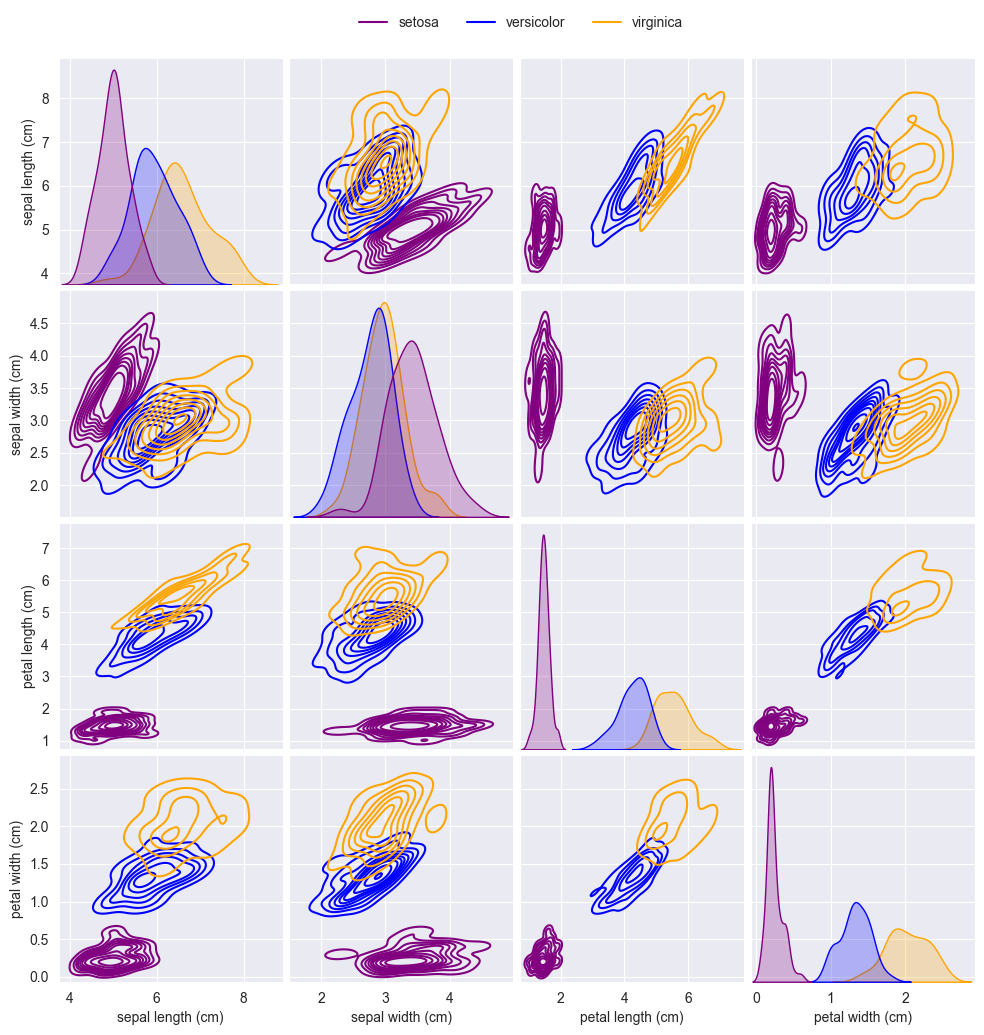

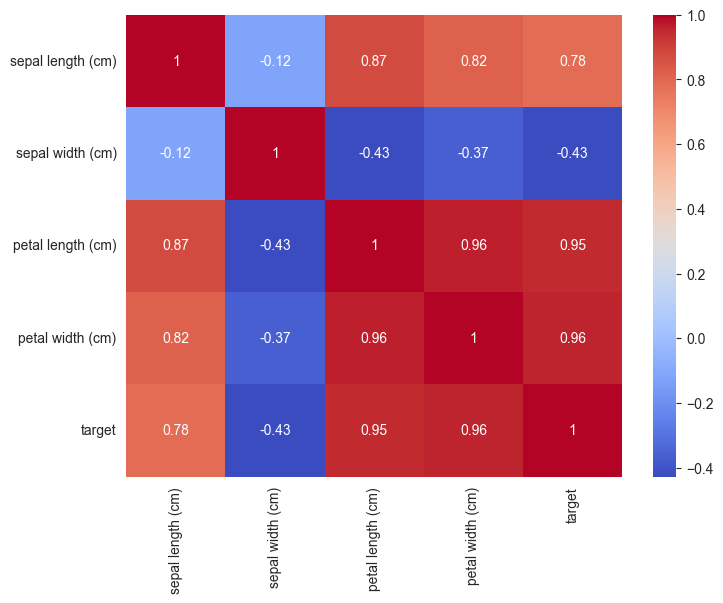

In [30]:
import pandas as pd

# создавање на DataFrame од податоците + target
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# пресметка на целата корелациска матрица со еден ред
correlation_matrix = df.corr()

# визуелизација
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

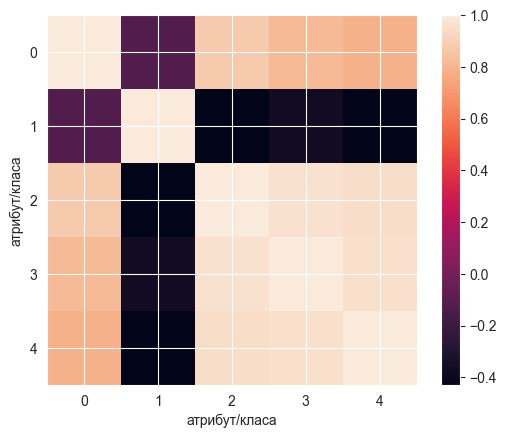

In [31]:
correlation_matrix = np.zeros((number_of_features+1,number_of_features+1))
# прво ги пресметуваме присоновите корелациски коефициенти за сите парови атрибути
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        corr, _ = stats.pearsonr(X[:,feature_i], X[:,feature_j])
        correlation_matrix[feature_i][feature_j] = corr
# потоа ги пресметуваме пирсоновите корелациски коефициенти за секој атрибут со целната променлива
for feature_i in range(number_of_features):
    target_i = number_of_features
    corr, _ = stats.pearsonr(X[:,feature_i], y)
    correlation_matrix[feature_i][target_i] = corr
    correlation_matrix[target_i][feature_i] = corr
# на крај го пресметуваме пирсоновиот корелациски коефициент за целната променлива само со себе (ова може и да се изостави зашто резултатот е 1)
corr, _ = stats.pearsonr(y, y)
correlation_matrix[target_i][target_i] = corr
corr, _ = stats.pearsonr(X[:,feature_i], y)

plt.figure()
plt.imshow(correlation_matrix)
plt.xlabel("атрибут/класа")
plt.ylabel("атрибут/класа")
plt.colorbar()
plt.show()

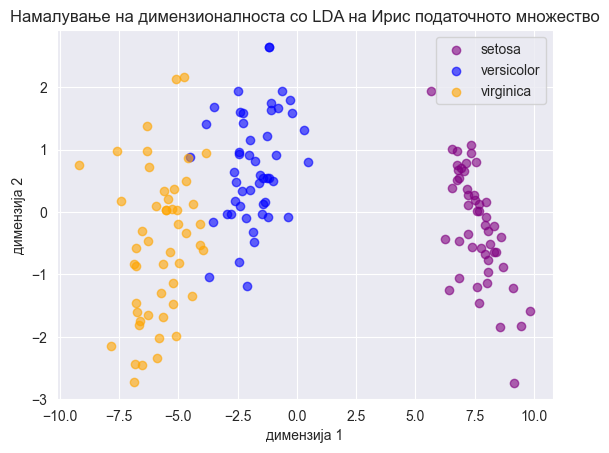

In [32]:
#reducirame dimenzii linearno praj 2 novi dimenzii so linearni kombinacii od starite 4
# pr Z1=0.5⋅sepal length+0.3⋅petal width−0.2⋅petal length


LDA_reduce = LinearDiscriminantAnalysis(n_components=2) # Го поставуваме бројот ан компоненти во новиот простор на 2
LDA_reduce.fit(X, y) # Го фитуваме LDA моделот на податоците X и y
X_reduced = LDA_reduce.transform(X) # Со помош на фитуваниот модел ги трансформираме влезните податоци X во но новите X_LDA

# Сега можеме да го визуелизираме податочното множество на еден дводимензионален график
plt.figure()

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_reduced[y == i, 0], X_reduced[y == i, 1], alpha=.6, color=color,
                label=target_name)
plt.legend()
plt.xlabel("димензија 1")
plt.ylabel("димензија 2")
plt.title('Намалување на димензионалноста со LDA на Ирис податочното множество')
plt.show()

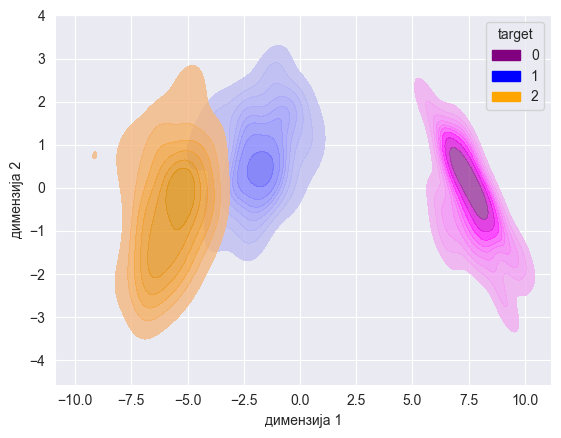

In [33]:
df['димензија 1']= pd.DataFrame(X_reduced[:,0])
df['димензија 2']= pd.DataFrame(X_reduced[:,1])
g=sns.kdeplot(data=df, x="димензија 1", y="димензија 2",hue="target",palette=colors,alpha=0.8,fill=True);

handles, labels = g.get_legend_handles_labels()
fig.legend(handles, target_names, labelcolor=colors, loc='lower center',bbox_to_anchor=(.5, 1), ncol=3,frameon=False)
plt.show()

In [34]:
#KLASIFIKACIJA

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Поделба на оригиналното множество на тренинг и тест множества
X_reduced_train, X_reduced_test, y_reduced_train, y_reduced_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42) # Поделба на редуцираното множество на тренинг и тест множества

In [36]:
QDA = QuadraticDiscriminantAnalysis() # иницијализација на моделот
QDA.fit(X_train, y_train); # нагодување на моделот на податоците од тренинг множеството

In [37]:
#priorni verojatnodti na sekoja klasa
print("Приорните веројатности на класите се",QDA.priors_)

Приорните веројатности на класите се [0.2952381  0.35238095 0.35238095]


In [38]:
y_pred = QDA.predict(X_test) # предвидување на лабелите од тест множеството со користење на нагодениот модел
QDA_accuracy = accuracy_score(y_test, y_pred) # пресметување на точност на предвидените лабели од тест множеството

print("Точноста на класификацијата со методот QDA во оригиналното Ирис податочно множество е",round(QDA_accuracy,3))

Точноста на класификацијата со методот QDA во оригиналното Ирис податочно множество е 1.0


In [39]:
LDA = LinearDiscriminantAnalysis() # иницијализација на моделот
LDA.fit(X_train, y_train) # нагодување на моделот на податоците од тренинг множеството
y_pred = LDA.predict(X_test) # предвидување на лабелите од тест множеството со користење на нагодениот модел
LDA_accuracy = accuracy_score(y_test, y_pred) # пресметување на точноста на предвидените лабели од тест множеството

print("Точноста на класификацијата со методот LDA во оригиналното Ирис податочно множество е",round(LDA_accuracy,3))

Точноста на класификацијата со методот LDA во оригиналното Ирис податочно множество е 1.0


In [40]:
GNB = GaussianNB() # иницијализација на моделот
GNB.fit(X_train, y_train) # нагодување на моделот на податоците од тренинг множеството
y_pred = GNB.predict(X_test) # предвидување на лабелите од тест множеството со користење на нагодениот модел
GNB_accuracy = accuracy_score(y_test, y_pred) # пресметување на точноста на предвидените лабели од тест множеството

print("Точноста на класификацијата со Гаусовиот наивен Баесов класификатор во оригиналното Ирис податочно множество е",round(GNB_accuracy,3))

Точноста на класификацијата со Гаусовиот наивен Баесов класификатор во оригиналното Ирис податочно множество е 0.978


In [41]:
#SEGA NA REDUCIRANOTO PDOATOCHNO MNOZHESTVO

In [42]:
QDA_reduced = QuadraticDiscriminantAnalysis() # иницијализација на моделот
QDA_reduced.fit(X_reduced_train, y_reduced_train) # нагодување на моделот на податоците од тренинг множеството
y_pred = QDA_reduced.predict(X_reduced_test) # предвидување на лабелите од тест множеството со користење на нагодениот модел
QDA_reduced_accuracy = accuracy_score(y_test, y_pred) # пресметување на точноста на предвидените лабели од тест множеството
print("Точноста на класификацијата со методот QDA во редуцираното Ирис податочно множество е",round(QDA_reduced_accuracy,3))

# Визуелизација на тест множеството и грешките при класификацијата
plt.figure()
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_reduced_test[y_test == i, 0], X_reduced_test[y_test == i, 1], alpha=.6, color=color,
                label=target_name)

incorrect = y_pred!=y_reduced_test
for i in range(len(incorrect)):
    if(incorrect[i]==True):
        plt.scatter(X_reduced_test[i][0], X_reduced_test[i][1], alpha=.6, color="black")

plt.legend()
plt.xlabel("димензија 1")
plt.ylabel("димензија 2")
plt.title('Класификација со QDA во редуцираното Ирис податочно множество');

Точноста на класификацијата со методот QDA во редуцираното Ирис податочно множество е 1.0


In [47]:
# Кога е слична, кога различна?
#
# Слична: Ако податоците за сите класи имаат ист “облик” и ориентација, тогаш LDA е добра.
#
# На пример, сите класи се кружни со ист радиус, само различно поставени.
#
# Различна: Ако класи имаат различен облик/ориентација/шири/високи, тогаш QDA е подобра.
#
# На пример, една класа е тенка и долга, друга е широка и ниска, трета кружна.

In [43]:
LDA_reduced = LinearDiscriminantAnalysis(solver='lsqr') # иницијализација на моделот
LDA_reduced.fit(X_reduced_train, y_reduced_train) # нагодување на моделот на податоците од тренинг множеството
y_pred = LDA_reduced.predict(X_reduced_test) # предвидување на лабелите од тест множеството со користење на нагодениот модел
LDA_reduced_accuracy = accuracy_score(y_test, y_pred) # пресметување на точноста на предвидените лабели од тест множеството
print("Точноста на класификацијата со методот LDA во редуцираното Ирис податочно множество е",round(LDA_reduced_accuracy,3))

# Визуелизација на тест множеството и грешките при класификацијата
plt.figure()
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_reduced_test[y_test == i, 0], X_reduced_test[y_test == i, 1], alpha=.6, color=color,
                label=target_name)

incorrect = y_pred!=y_reduced_test
for i in range(len(incorrect)):
    if(incorrect[i]==True):
        plt.scatter(X_reduced_test[i][0], X_reduced_test[i][1], alpha=.6, color="black")

plt.legend()
plt.xlabel("димензија 1")
plt.ylabel("димензија 2")
plt.title('Класификација со LDA во редуцираното Ирис податочно множество');

Точноста на класификацијата со методот LDA во редуцираното Ирис податочно множество е 1.0


In [44]:
GNB_reduced = GaussianNB() # иницијализација на моделот
GNB_reduced.fit(X_reduced_train, y_reduced_train) # нагодување на моделот на податоците од тренинг множеството
y_pred = GNB_reduced.predict(X_reduced_test) # предвидување на лабелите од тест множеството со користење на нагодениот модел
GNB_reduced_accuracy = accuracy_score(y_test, y_pred) # пресметување на точноста на предвидените лабели од тест множеството
print("Точноста на класификацијата со Гаусов наивен Баесов класификатор во редуцираното Ирис податочно множество е",round(GNB_reduced_accuracy,3))

# Визуелизација на тест множеството и грешките при класификацијата
plt.figure()
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_reduced_test[y_test == i, 0], X_reduced_test[y_test == i, 1], alpha=.6, color=color,
                label=target_name)

incorrect = y_pred!=y_reduced_test
for i in range(len(incorrect)):
    if(incorrect[i]==True):
        plt.scatter(X_reduced_test[i][0], X_reduced_test[i][1], alpha=.6, color="black")

plt.legend()
plt.xlabel("димензија 1")
plt.ylabel("димензија 2")
plt.title('Класификација со GNB во редуцираното Ирис податочно множество');


Точноста на класификацијата со Гаусов наивен Баесов класификатор во редуцираното Ирис податочно множество е 1.0


In [45]:
#Визуелизација на истренирани модели